# DDPM reverse timestep trajectory analysis

This notebook opens the DDPM black box by recording the reverse Markov chain itself.

For one selected LR condition image, it runs a custom reverse diffusion loop and captures non-linearly spaced snapshots. For each snapshot it can visualize:

- the current denoised image state `x_t`
- final reconstruction contours overlaid on every earlier state
- conditional guidance residual: `x_t - LR condition`
- predicted noise scalar field
- a quiver/vector proxy derived from the spatial gradient of predicted noise
- total flux convergence
- FWHM / morphology-width convergence

For single-channel maps, `predicted_noise` is a scalar field, not a native 2D vector field. The quiver plot uses `-∇ predicted_noise` as a visual proxy for the local score-flow direction toward higher-probability structure.


In [1]:
from pathlib import Path
import importlib
import json
import math
import sys
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib.colors import PowerNorm
from tqdm.auto import tqdm

plt.rcParams["figure.dpi"] = 120


def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "codes").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not find repo root containing both codes/ and data/.")


ADDR_ROOT = find_repo_root()
ADDR_CODE = ADDR_ROOT / "codes"
ADDR_MODELS = ADDR_CODE / "models"
for path in [ADDR_ROOT, ADDR_CODE, ADDR_MODELS]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.append(path_str)

from codes.config.config_DDPM import ModelConfig

print(f"ADDR_ROOT = {ADDR_ROOT}")
print(f"ADDR_CODE = {ADDR_CODE}")
print(f"CUDA available = {torch.cuda.is_available()}")


ADDR_ROOT = /root/LHAI_novel
ADDR_CODE = /root/LHAI_novel/codes
CUDA available = True


/root/miniconda3/envs/LHAI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PREDICT_DIR = ADDR_ROOT / "data" / "Predict"
PREDICT_NPY_NAME = "HESSexcess_2_64_predict.npy"
PREDICT_NPY_PATH = None

SAMPLE_INDEX = 0
INPUT_CHANNEL = 1
TARGET_CHANNEL = 0
SAMPLE_SELECTOR = None
GT_NPY_PATH = None
GT_SAMPLE_INDEX = None
GT_SAMPLE_SELECTOR = None

MODEL_WEIGHT_DIR = ADDR_ROOT / "saves" / "MODEL" / "DDPM"
MODEL_WEIGHT_NAME = "Last_DDPM_EXP01_400epo_32bth_64size_SR4excess.pth"
MODEL_WEIGHT_PATH = None

DIFFUSION_CONFIG_KEY = "DDPM_64"
DIFFUSION_MODULE_NAME = "DDPM"
DIFFUSION_CLASS_NAME = "DDPM"
UNET_CONFIG_KEY = "UNET"
UNET_MODULE_NAME = "UNET"
UNET_CLASS_NAME = "UNET"

DATA_RANGE = 2.0
BASE_SEED = 2026
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
STRICT_LOAD = True
CLAMP_OUTPUT = False
OVERRIDE_IMG_SIZE_FROM_DATA = True

SNAPSHOT_MODE = "edge_dense"
N_SNAPSHOTS = 12
CUSTOM_SNAPSHOT_STEPS = None
SAVE_PREDICTED_NOISE = True

COUNTS_RESTORE_MODE = "input_mass_match"
CLIP_FOR_COUNTS = True
EPS_COUNTS = 1e-8

CONTOUR_PERCENTILES = (70, 82, 90, 96)
FWHM_CENTER_MODE = "final_peak"
FWHM_CENTER_YX = None
FWHM_RADIAL_BIN_WIDTH = 1.0
QUIVER_STRIDE = 6
QUIVER_SCALE = None

VIS_CMAP_IMAGE = "viridis"
VIS_CMAP_RESIDUAL = "coolwarm"
VIS_CMAP_NOISE = "RdBu_r"
ENHANCED_COUNTS_STYLE = True
SAVE_OUTPUTS = True
OUTPUT_DIR = ADDR_ROOT / "saves" / "PREDICT" / "DDPM" / "TimeStep"


In [3]:
def show_available_files():
    predict_files = sorted(PREDICT_DIR.glob("*.npy")) if PREDICT_DIR.exists() else []
    weight_files = sorted(MODEL_WEIGHT_DIR.glob("*.pth")) if MODEL_WEIGHT_DIR.exists() else []
    print("Available predict .npy files:")
    for path in predict_files:
        print(f"  {path.name}")
    if not predict_files:
        print(f"  No .npy files found in {PREDICT_DIR}; set PREDICT_NPY_PATH manually if needed.")
    print("\nAvailable DDPM weights:")
    for path in weight_files:
        print(f"  {path.name}")
    if not weight_files:
        print(f"  No .pth files found in {MODEL_WEIGHT_DIR}; set MODEL_WEIGHT_PATH manually if needed.")
    print("\nSelection hints:")
    print("  (H,W): selected directly")
    print("  (N,H,W): SAMPLE_INDEX selects N")
    print("  (N,C,H,W): SAMPLE_INDEX selects N, INPUT_CHANNEL selects C")
    print("  arbitrary (...,H,W): set SAMPLE_SELECTOR to a tuple selecting all leading dimensions")


show_available_files()

if PREDICT_NPY_PATH is None:
    if PREDICT_NPY_NAME is None:
        raise ValueError("Set PREDICT_NPY_NAME or PREDICT_NPY_PATH in the configuration cell.")
    predict_path = PREDICT_DIR / PREDICT_NPY_NAME
else:
    predict_path = Path(PREDICT_NPY_PATH)

if MODEL_WEIGHT_PATH is None:
    if MODEL_WEIGHT_NAME is None:
        raise ValueError("Set MODEL_WEIGHT_NAME or MODEL_WEIGHT_PATH in the configuration cell.")
    model_weight_path = MODEL_WEIGHT_DIR / MODEL_WEIGHT_NAME
else:
    model_weight_path = Path(MODEL_WEIGHT_PATH)

if not predict_path.exists():
    raise FileNotFoundError(predict_path)
if not model_weight_path.exists():
    raise FileNotFoundError(model_weight_path)

print(f"Selected predict data: {predict_path}")
print(f"Selected model weight: {model_weight_path}")


Available predict .npy files:
  ECAexcess_300_64_test.npy
  HESS_2_64_Predict_conv.npy
  HESSbkgon_2_128_predict.npy
  HESSbkgon_2_64_predict.npy
  HESSexcess_2_128_predict.npy
  HESSexcess_2_64_predict.npy
  HESSpoisonon_2_128_predict.npy
  HESSpoisonon_2_64_predict.npy
  RSAexcess_500_64_test.npy

Available DDPM weights:
  Last_DDPM_EXP01_400epo_32bth_128size_SR4bkgon.pth
  Last_DDPM_EXP01_400epo_32bth_128size_SR4excess.pth
  Last_DDPM_EXP01_400epo_32bth_128size_SR4poisonon.pth
  Last_DDPM_EXP01_400epo_32bth_64size_SR4bkgon.pth
  Last_DDPM_EXP01_400epo_32bth_64size_SR4excess.pth
  Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.pth

Selection hints:
  (H,W): selected directly
  (N,H,W): SAMPLE_INDEX selects N
  (N,C,H,W): SAMPLE_INDEX selects N, INPUT_CHANNEL selects C
  arbitrary (...,H,W): set SAMPLE_SELECTOR to a tuple selecting all leading dimensions
Selected predict data: /root/LHAI_novel/data/Predict/HESSexcess_2_64_predict.npy
Selected model weight: /root/LHAI_novel/saves/MODE

In [4]:
def _as_float32(array):
    return np.asarray(array, dtype=np.float32)


def _select_image_from_array(array, sample_index=0, channel=None, selector=None, role="input"):
    array = np.asarray(array)
    if selector is not None:
        selected = array[tuple(selector)]
        if selected.ndim == 2:
            return _as_float32(selected)
        if selected.ndim == 3:
            if channel is None:
                channel = 0 if selected.shape[0] <= 8 else None
            if channel is not None and selected.shape[0] <= 8:
                return _as_float32(selected[channel])
        raise ValueError(f"{role}: SAMPLE_SELECTOR must select an image or channel stack ending in (H,W), got {selected.shape}")
    if array.ndim == 2:
        return _as_float32(array)
    if array.ndim == 3:
        if array.shape[0] <= 8 and array.shape[1] == array.shape[2] and channel is not None:
            return _as_float32(array[channel])
        if sample_index >= array.shape[0]:
            raise IndexError(f"{role}: SAMPLE_INDEX={sample_index} out of range for shape {array.shape}")
        return _as_float32(array[sample_index])
    if array.ndim == 4:
        if sample_index >= array.shape[0]:
            raise IndexError(f"{role}: SAMPLE_INDEX={sample_index} out of range for shape {array.shape}")
        sample = array[sample_index]
        if channel is None:
            if sample.shape[0] == 1:
                channel = 0
            elif sample.shape[0] >= 2:
                channel = 1 if role == "input" else 0
            else:
                raise ValueError(f"{role}: cannot infer channel for shape {array.shape}")
        return _as_float32(sample[channel])
    if array.ndim > 4:
        raise ValueError(f"{role}: array has shape {array.shape}; set SAMPLE_SELECTOR/GT_SAMPLE_SELECTOR manually.")
    raise ValueError(f"{role}: expected shape (H,W), (N,H,W), (C,H,W), (N,C,H,W), or selector for (...,H,W), got {array.shape}")


def minmax_normalize_image(image, data_range=1.0):
    image = _as_float32(image)
    vmin = float(np.min(image))
    vmax = float(np.max(image))
    norm01 = (image - vmin) / max(vmax - vmin, 1e-8)
    if abs(data_range - 1.0) < 1e-6:
        return norm01.astype(np.float32), vmin, vmax
    if abs(data_range - 2.0) < 1e-6:
        return (2.0 * norm01 - 1.0).astype(np.float32), vmin, vmax
    raise ValueError("DATA_RANGE must be 1.0 or 2.0")


def normalized_to_unit_interval(array):
    array = np.asarray(array, dtype=np.float32)
    if abs(DATA_RANGE - 2.0) < 1e-6:
        unit = 0.5 * (array + 1.0)
    elif abs(DATA_RANGE - 1.0) < 1e-6:
        unit = array
    else:
        raise ValueError("DATA_RANGE must be 1.0 or 2.0")
    return np.clip(unit, 0.0, 1.0) if CLIP_FOR_COUNTS else unit


def resize_2d(image, size):
    image = _as_float32(image)
    if image.shape == (size, size):
        return image
    tensor = torch.from_numpy(image[None, None]).float()
    return F.interpolate(tensor, size=(size, size), mode="bilinear", align_corners=False)[0, 0].numpy()


predict_array = np.load(predict_path, allow_pickle=True)
input_counts = _select_image_from_array(predict_array, SAMPLE_INDEX, INPUT_CHANNEL, SAMPLE_SELECTOR, role="input")
input_norm, input_min, input_max = minmax_normalize_image(input_counts, DATA_RANGE)

target_counts = None
if GT_NPY_PATH is not None:
    gt_array = np.load(Path(GT_NPY_PATH), allow_pickle=True)
    gt_idx = SAMPLE_INDEX if GT_SAMPLE_INDEX is None else GT_SAMPLE_INDEX
    target_counts = _select_image_from_array(gt_array, gt_idx, TARGET_CHANNEL, GT_SAMPLE_SELECTOR, role="target")
elif np.asarray(predict_array).ndim == 4 and np.asarray(predict_array).shape[1] >= 2:
    target_counts = _select_image_from_array(predict_array, SAMPLE_INDEX, 0 if TARGET_CHANNEL is None else TARGET_CHANNEL, None, role="target")

target_norm = None
if target_counts is not None:
    target_norm, target_min, target_max = minmax_normalize_image(target_counts, DATA_RANGE)

print(f"predict array shape: {np.asarray(predict_array).shape}")
print(f"selected input shape: {input_counts.shape}, min={input_counts.min():.4g}, max={input_counts.max():.4g}, sum={input_counts.sum():.4g}")
if target_counts is not None:
    print(f"selected GT shape: {target_counts.shape}, min={target_counts.min():.4g}, max={target_counts.max():.4g}, sum={target_counts.sum():.4g}")
else:
    print("No GT target provided; trajectory analysis will omit GT overlays/curves.")


predict array shape: (2, 2, 64, 64)
selected input shape: (64, 64), min=32.54, max=1772, sum=2.643e+05
selected GT shape: (64, 64), min=0, max=2920, sum=6.112e+04


In [5]:
def import_model_class(module_name, class_name):
    module = importlib.import_module(f"codes.models.{module_name}")
    return getattr(module, class_name)


model_cfg = ModelConfig()
model_params = model_cfg.model_params
condition_size = int(input_norm.shape[-1])
if input_norm.shape[-1] != input_norm.shape[-2]:
    raise ValueError(f"Input image must be square for current DDPM implementation, got {input_norm.shape}")

if DIFFUSION_CONFIG_KEY is None:
    if condition_size == 128 and "DDPM128" in model_params:
        DIFFUSION_CONFIG_KEY = "DDPM128"
    elif condition_size == 64 and "DDPM_64" in model_params:
        DIFFUSION_CONFIG_KEY = "DDPM_64"
    elif "DDPM" in model_params:
        DIFFUSION_CONFIG_KEY = "DDPM"
    else:
        raise KeyError("Could not infer DIFFUSION_CONFIG_KEY. Set it manually.")

if DIFFUSION_CONFIG_KEY not in model_params:
    raise KeyError(f"{DIFFUSION_CONFIG_KEY=} not found in ModelConfig.model_params")
if UNET_CONFIG_KEY not in model_params:
    raise KeyError(f"{UNET_CONFIG_KEY=} not found in ModelConfig.model_params")

params_diffusion = dict(model_params[DIFFUSION_CONFIG_KEY])
params_unet = dict(model_params[UNET_CONFIG_KEY])
image_size = int(params_diffusion.get("img_size", condition_size))
if OVERRIDE_IMG_SIZE_FROM_DATA and params_diffusion.get("img_size") != condition_size:
    print(f"Overriding diffusion img_size from {params_diffusion.get('img_size')} to input condition size {condition_size}.")
    image_size = condition_size
    params_diffusion["img_size"] = image_size
params_diffusion["device"] = torch.device(DEVICE)

device = torch.device(DEVICE)
DIFFUSION = import_model_class(DIFFUSION_MODULE_NAME, DIFFUSION_CLASS_NAME)
UNET = import_model_class(UNET_MODULE_NAME, UNET_CLASS_NAME)

diffusion = DIFFUSION(**params_diffusion)
unet = UNET(**params_unet).to(device)
if hasattr(unet, "build"):
    unet.build()
unet.to(device)
state = torch.load(model_weight_path, map_location=device)
if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]
unet.load_state_dict(state, strict=STRICT_LOAD)
unet.eval()

condition_norm = resize_2d(input_norm, image_size)
condition_tensor = torch.from_numpy(condition_norm[None, None]).float().to(device)
input_counts_resized = resize_2d(input_counts, image_size)
target_counts_resized = resize_2d(target_counts, image_size) if target_counts is not None else None

print(f"Device: {device}")
print(f"Diffusion config key: {DIFFUSION_CONFIG_KEY}")
print(f"noise_steps: {diffusion.noise_steps}")
print(f"Image size: {image_size}")
print(f"Condition tensor shape: {tuple(condition_tensor.shape)}")


Device: cuda
Diffusion config key: DDPM_64
noise_steps: 2000
Image size: 64
Condition tensor shape: (1, 1, 64, 64)


In [6]:
def make_snapshot_steps(noise_steps, n_snapshots=12, mode="edge_dense", custom_steps=None):
    if custom_steps is not None:
        steps = np.asarray(custom_steps, dtype=int)
    elif mode == "log":
        dense_low = np.geomspace(1, noise_steps, n_snapshots)
        steps = noise_steps - np.round(dense_low).astype(int)
    elif mode == "edge_dense":
        u = np.linspace(0.0, 1.0, n_snapshots)
        left = 0.5 * (1.0 - np.cos(np.pi * u))
        steps = np.round((noise_steps - 1) * (1.0 - left)).astype(int)
    elif mode == "manual_default":
        fractions = np.array([0.999, 0.95, 0.85, 0.70, 0.50, 0.30, 0.15, 0.08, 0.04, 0.02, 0.005, 0.0])
        steps = np.round((noise_steps - 1) * fractions).astype(int)
    else:
        raise ValueError("SNAPSHOT_MODE must be edge_dense, log, manual_default, or use CUSTOM_SNAPSHOT_STEPS")
    steps = np.unique(np.clip(steps, 0, noise_steps - 1))[::-1]
    if steps[-1] != 0:
        steps = np.r_[steps, 0]
    return [int(s) for s in steps]


snapshot_steps = make_snapshot_steps(diffusion.noise_steps, N_SNAPSHOTS, SNAPSHOT_MODE, CUSTOM_SNAPSHOT_STEPS)
print("Snapshot timesteps, high noise -> final:")
print(snapshot_steps)


Snapshot timesteps, high noise -> final:
[1999, 1959, 1840, 1654, 1415, 1142, 857, 584, 345, 159, 40, 0]


In [7]:
def restore_norm_to_counts(image_norm):
    unit = normalized_to_unit_interval(image_norm)
    if COUNTS_RESTORE_MODE == "input_minmax":
        return unit * max(input_max - input_min, EPS_COUNTS) + input_min
    if COUNTS_RESTORE_MODE == "input_mass_match":
        reference = np.clip(input_counts_resized, 0.0, None)
    elif COUNTS_RESTORE_MODE == "target_mass_match":
        if target_counts_resized is None:
            raise ValueError("target_mass_match requires GT target.")
        reference = np.clip(target_counts_resized, 0.0, None)
    else:
        raise ValueError("COUNTS_RESTORE_MODE must be input_minmax, input_mass_match, or target_mass_match")
    unit_pos = np.clip(unit, 0.0, None)
    return unit_pos * (reference.sum() / max(unit_pos.sum(), EPS_COUNTS))


def image_flux(image):
    return float(np.clip(image, 0.0, None).sum())


def fwhm_from_image(image, center_yx=None, bin_width=1.0):
    image = np.asarray(image, dtype=np.float64)
    if center_yx is None:
        center_yx = np.unravel_index(int(np.nanargmax(image)), image.shape)
    yy, xx = np.indices(image.shape)
    rr = np.sqrt((yy - center_yx[0]) ** 2 + (xx - center_yx[1]) ** 2)
    bins = np.floor(rr / bin_width).astype(int)
    nbins = bins.max() + 1
    radial = np.full(nbins, np.nan)
    radii = (np.arange(nbins) + 0.5) * bin_width
    for b in range(nbins):
        mask = bins == b
        if np.any(mask):
            radial[b] = image[mask].mean()
    peak = np.nanmax(radial)
    if not np.isfinite(peak) or peak <= 0:
        return float("nan")
    half = 0.5 * peak
    valid = np.where(np.isfinite(radial) & (radial <= half))[0]
    if valid.size == 0:
        return float("nan")
    first = valid[0]
    if first == 0:
        radius_half = radii[0]
    else:
        x0, x1 = radii[first - 1], radii[first]
        y0, y1 = radial[first - 1], radial[first]
        radius_half = x1 if y1 == y0 else x0 + (half - y0) * (x1 - x0) / (y1 - y0)
    return float(2.0 * radius_half)


@torch.no_grad()
def reverse_with_snapshots(model, diffusion, input_image, snapshot_steps, seed=0):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    model.eval()
    n_images = input_image.shape[0]
    n_channels = 1
    device = diffusion.device
    x = torch.randn((n_images, n_channels, diffusion.img_size, diffusion.img_size), device=device)
    input_image = input_image.to(device)
    alpha = diffusion.alpha.to(device)
    alpha_bar = diffusion.alpha_bar.to(device)
    snapshot_set = set(snapshot_steps)
    snapshots = {}
    noise_predictions = {}
    flux_curve = []
    fwhm_curve = []
    final_center = None
    for i in tqdm(reversed(range(0, diffusion.noise_steps)), desc="Reverse trajectory", total=diffusion.noise_steps):
        t = torch.full((n_images,), i, dtype=torch.long, device=device)
        t_emb = diffusion._positional_encoding(t)
        xt_input = torch.cat([input_image, x], dim=1) if diffusion.conditional else x
        predicted_noise = model(xt_input, t_emb)
        alpha_t = alpha[t][:, None, None, None]
        alpha_bar_t = alpha_bar[t][:, None, None, None]
        noise = torch.randn_like(x) if i > 0 else torch.zeros_like(x)
        x = (1.0 / torch.sqrt(alpha_t)) * (
            x - ((1.0 - alpha_t) / torch.sqrt(1.0 - alpha_bar_t)) * predicted_noise
        ) + torch.sqrt(1.0 - alpha_t) * noise
        x_np = x[0, 0].detach().cpu().numpy()
        x_counts = restore_norm_to_counts(x_np)
        flux_curve.append((i, image_flux(x_counts)))
        if final_center is None and i == 0:
            final_center = np.unravel_index(int(np.nanargmax(x_counts)), x_counts.shape)
        center = FWHM_CENTER_YX if FWHM_CENTER_YX is not None else (final_center if final_center is not None else np.unravel_index(int(np.nanargmax(x_counts)), x_counts.shape))
        fwhm_curve.append((i, fwhm_from_image(x_counts, center, FWHM_RADIAL_BIN_WIDTH)))
        if i in snapshot_set:
            snapshots[i] = x_np.copy()
            if SAVE_PREDICTED_NOISE:
                noise_predictions[i] = predicted_noise[0, 0].detach().cpu().numpy().copy()
    if 0 not in snapshots:
        snapshots[0] = x[0, 0].detach().cpu().numpy().copy()
        if SAVE_PREDICTED_NOISE:
            noise_predictions[0] = predicted_noise[0, 0].detach().cpu().numpy().copy()
    return snapshots, noise_predictions, np.asarray(flux_curve), np.asarray(fwhm_curve)


snapshots_norm, noise_predictions, flux_curve, fwhm_curve = reverse_with_snapshots(
    unet, diffusion, condition_tensor, snapshot_steps, seed=BASE_SEED
)
snapshots_counts = {t: restore_norm_to_counts(img) for t, img in snapshots_norm.items()}
final_counts = snapshots_counts[min(snapshots_counts.keys())]
print(f"Captured {len(snapshots_counts)} image snapshots and {len(noise_predictions)} predicted-noise snapshots.")


Reverse trajectory: 100%|██████████| 2000/2000 [00:06<00:00, 317.50it/s]

Captured 12 image snapshots and 12 predicted-noise snapshots.


Saved trajectory figure: /root/LHAI_novel/saves/PREDICT/DDPM/TimeStep/trajectory_evolution__HESSexcess_2_64_predict__idx0__Last_DDPM_EXP01_400epo_32bth_64size_SR4excess.png


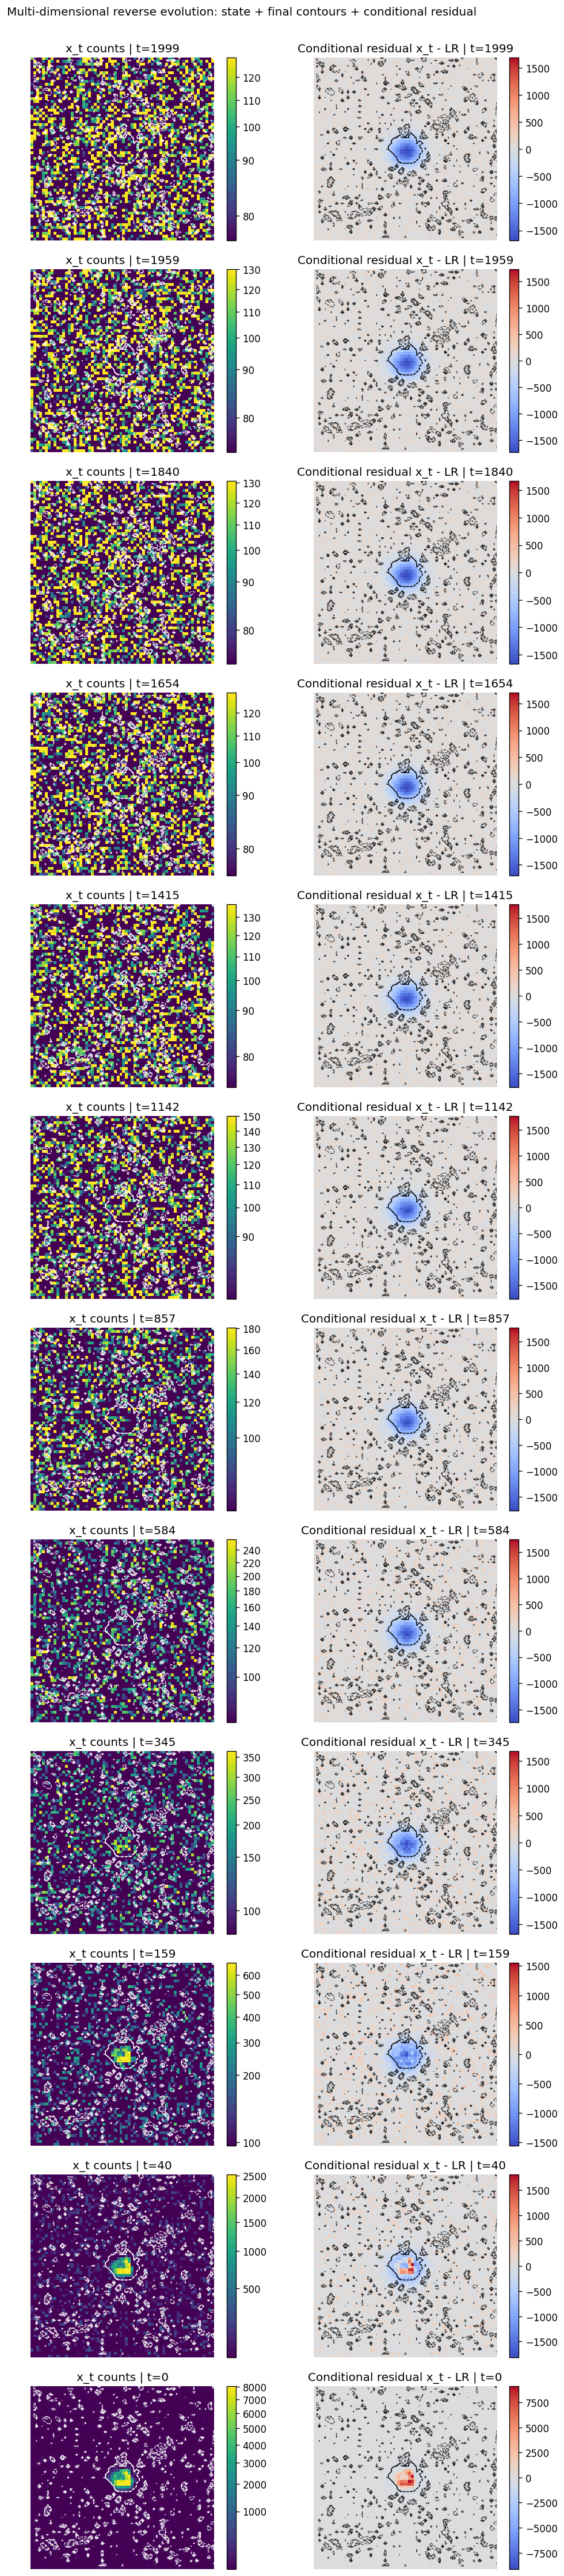

In [8]:
def get_display_limits(image, floor_percentile=50, ceil_percentile=99.7):
    positive = image[np.isfinite(image) & (image > 0)]
    if positive.size == 0:
        finite = image[np.isfinite(image)]
        if finite.size == 0:
            return 0.0, 1.0
        return float(np.nanmin(finite)), float(np.nanmax(finite) + 1e-6)
    vmin = float(np.percentile(positive, floor_percentile))
    vmax = float(np.percentile(positive, ceil_percentile))
    if vmax <= vmin:
        vmax = float(positive.max())
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return vmin, vmax


def contour_levels(image, percentiles=CONTOUR_PERCENTILES):
    positive = image[image > 0]
    if positive.size == 0:
        return []
    levels = np.percentile(positive, percentiles)
    levels = np.unique(levels[levels > 0])
    return levels if levels.size >= 2 else []


def show_image(ax, image, title, cmap=VIS_CMAP_IMAGE, enhanced=True):
    if enhanced:
        vmin, vmax = get_display_limits(image)
        im = ax.imshow(image, origin="lower", cmap=cmap, norm=PowerNorm(gamma=0.55, vmin=vmin, vmax=vmax), interpolation="nearest")
    else:
        im = ax.imshow(image, origin="lower", cmap=cmap, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
    return im


ordered_steps = sorted(snapshots_counts.keys(), reverse=True)
final_levels = contour_levels(final_counts)
nrows = len(ordered_steps)
fig, axes = plt.subplots(nrows, 2, figsize=(9.5, 3.1 * nrows), squeeze=False)
for row, t in enumerate(ordered_steps):
    image = snapshots_counts[t]
    residual = image - input_counts_resized
    im0 = show_image(axes[row, 0], image, f"x_t counts | t={t}")
    if len(final_levels) > 0:
        axes[row, 0].contour(final_counts, levels=final_levels, origin="lower", colors="white", linestyles="--", linewidths=0.8, alpha=0.9)
    plt.colorbar(im0, ax=axes[row, 0], fraction=0.046, pad=0.04)
    vmax = np.nanmax(np.abs(residual))
    vmax = float(vmax if vmax > 0 else 1e-6)
    im1 = axes[row, 1].imshow(residual, origin="lower", cmap=VIS_CMAP_RESIDUAL, vmin=-vmax, vmax=vmax, interpolation="nearest")
    axes[row, 1].set_title(f"Conditional residual x_t - LR | t={t}")
    axes[row, 1].axis("off")
    if len(final_levels) > 0:
        axes[row, 1].contour(final_counts, levels=final_levels, origin="lower", colors="black", linestyles="--", linewidths=0.7, alpha=0.8)
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046, pad=0.04)
fig.suptitle("Multi-dimensional reverse evolution: state + final contours + conditional residual", y=1.002)
fig.tight_layout()
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig_path = OUTPUT_DIR / f"trajectory_evolution__{predict_path.stem}__idx{SAMPLE_INDEX}__{model_weight_path.stem}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"Saved trajectory figure: {fig_path}")
plt.show()


Saved convergence curves: /root/LHAI_novel/saves/PREDICT/DDPM/TimeStep/physical_convergence__HESSexcess_2_64_predict__idx0__Last_DDPM_EXP01_400epo_32bth_64size_SR4excess.png


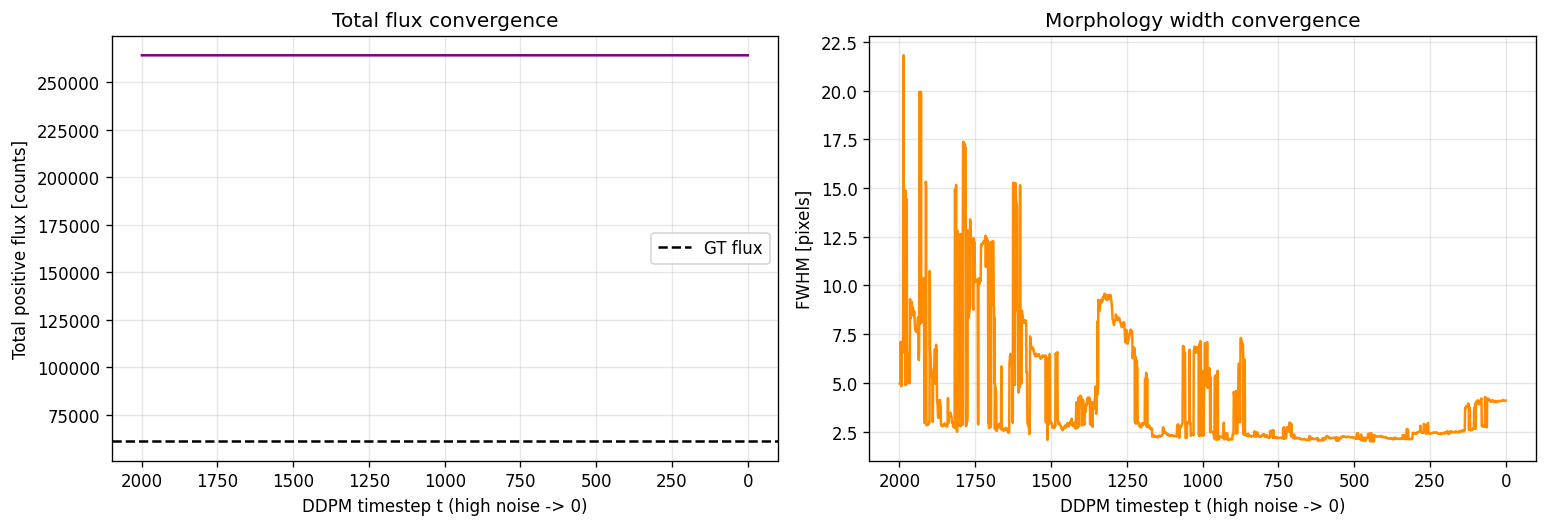

In [9]:
flux_sorted = flux_curve[np.argsort(flux_curve[:, 0])[::-1]]
fwhm_sorted = fwhm_curve[np.argsort(fwhm_curve[:, 0])[::-1]]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(flux_sorted[:, 0], flux_sorted[:, 1], color="purple")
axes[0].invert_xaxis()
axes[0].set_xlabel("DDPM timestep t (high noise -> 0)")
axes[0].set_ylabel("Total positive flux [counts]")
axes[0].set_title("Total flux convergence")
axes[0].grid(True, alpha=0.3)
if target_counts_resized is not None:
    axes[0].axhline(np.clip(target_counts_resized, 0.0, None).sum(), color="black", linestyle="--", label="GT flux")
    axes[0].legend()
axes[1].plot(fwhm_sorted[:, 0], fwhm_sorted[:, 1], color="darkorange")
axes[1].invert_xaxis()
axes[1].set_xlabel("DDPM timestep t (high noise -> 0)")
axes[1].set_ylabel("FWHM [pixels]")
axes[1].set_title("Morphology width convergence")
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig_path = OUTPUT_DIR / f"physical_convergence__{predict_path.stem}__idx{SAMPLE_INDEX}__{model_weight_path.stem}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"Saved convergence curves: {fig_path}")
plt.show()


Saved predicted-noise quiver figure: /root/LHAI_novel/saves/PREDICT/DDPM/TimeStep/predicted_noise_quiver__HESSexcess_2_64_predict__idx0__Last_DDPM_EXP01_400epo_32bth_64size_SR4excess.png


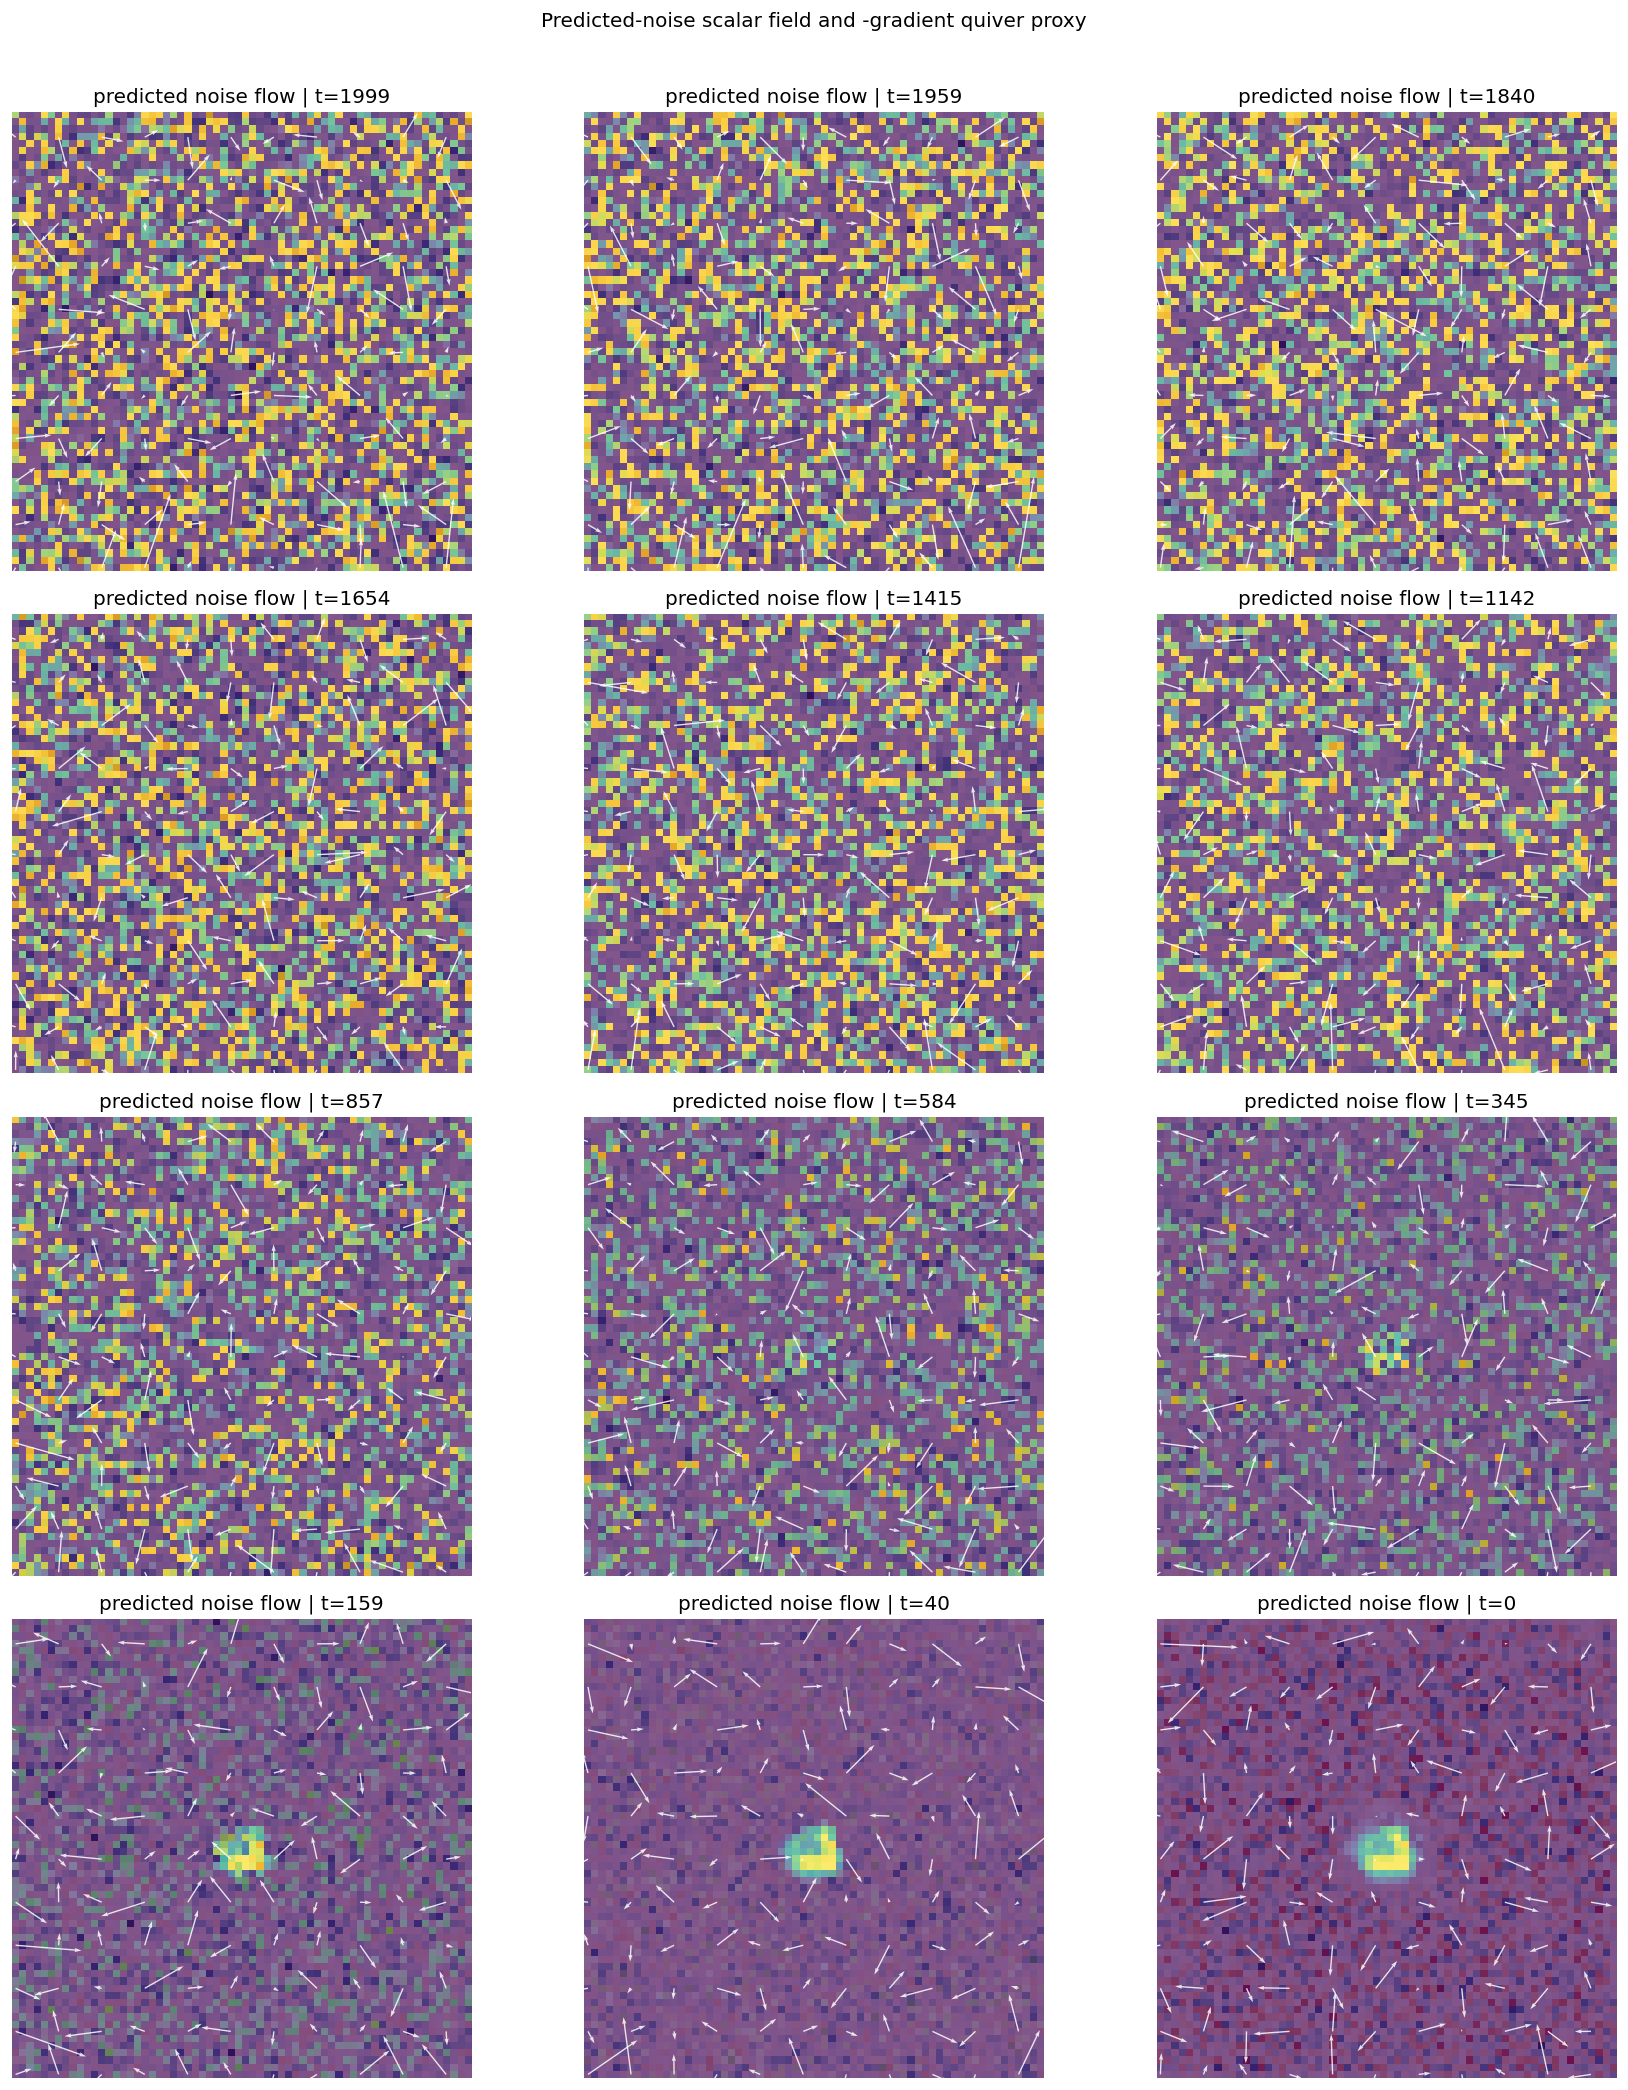

In [10]:
def quiver_from_scalar_noise(noise_map, stride=6):
    gy, gx = np.gradient(-noise_map)
    yy, xx = np.mgrid[0:noise_map.shape[0]:stride, 0:noise_map.shape[1]:stride]
    return xx, yy, gx[::stride, ::stride], gy[::stride, ::stride]


noise_steps_to_show = [t for t in ordered_steps if t in noise_predictions]
cols = 3
rows = math.ceil(len(noise_steps_to_show) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(5.0 * cols, 4.3 * rows), squeeze=False)
for ax in axes.ravel():
    ax.axis("off")
for ax, t in zip(axes.ravel(), noise_steps_to_show):
    image = snapshots_counts[t]
    noise_map = noise_predictions[t]
    show_image(ax, image, f"predicted noise flow | t={t}", cmap=VIS_CMAP_IMAGE)
    vmax_noise = np.nanmax(np.abs(noise_map))
    vmax_noise = float(vmax_noise if vmax_noise > 0 else 1e-6)
    ax.imshow(noise_map, origin="lower", cmap=VIS_CMAP_NOISE, alpha=0.35, vmin=-vmax_noise, vmax=vmax_noise, interpolation="nearest")
    xx, yy, uu, vv = quiver_from_scalar_noise(noise_map, QUIVER_STRIDE)
    ax.quiver(xx, yy, uu, vv, color="white", angles="xy", scale_units="xy", scale=QUIVER_SCALE, width=0.003, alpha=0.85)
fig.suptitle("Predicted-noise scalar field and -gradient quiver proxy", y=1.01)
fig.tight_layout()
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig_path = OUTPUT_DIR / f"predicted_noise_quiver__{predict_path.stem}__idx{SAMPLE_INDEX}__{model_weight_path.stem}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"Saved predicted-noise quiver figure: {fig_path}")
plt.show()


In [11]:
summary = {
    "data_path": str(predict_path),
    "sample_index": int(SAMPLE_INDEX),
    "sample_selector": None if SAMPLE_SELECTOR is None else list(SAMPLE_SELECTOR),
    "model_weight_path": str(model_weight_path),
    "diffusion_config_key": DIFFUSION_CONFIG_KEY,
    "noise_steps": int(diffusion.noise_steps),
    "snapshot_steps": [int(t) for t in ordered_steps],
    "data_range": DATA_RANGE,
    "counts_restore_mode": COUNTS_RESTORE_MODE,
    "final_flux_counts": float(image_flux(final_counts)),
    "final_fwhm_pixels": float(fwhm_from_image(final_counts, FWHM_CENTER_YX, FWHM_RADIAL_BIN_WIDTH)),
    "created_at": datetime.now().isoformat(timespec="seconds"),
}
if target_counts_resized is not None:
    summary["gt_flux_counts"] = float(np.clip(target_counts_resized, 0.0, None).sum())
    summary["final_mae_to_gt_counts"] = float(np.mean(np.abs(final_counts - target_counts_resized)))
print(json.dumps(summary, ensure_ascii=False, indent=2))

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    stem = f"{predict_path.stem}__idx{SAMPLE_INDEX}__{model_weight_path.stem}"
    np.savez_compressed(
        OUTPUT_DIR / f"trajectory_snapshots__{stem}.npz",
        timesteps=np.asarray(ordered_steps, dtype=np.int32),
        snapshots_norm=np.stack([snapshots_norm[t] for t in ordered_steps]).astype(np.float32),
        snapshots_counts=np.stack([snapshots_counts[t] for t in ordered_steps]).astype(np.float32),
        predicted_noise=np.stack([noise_predictions[t] for t in ordered_steps if t in noise_predictions]).astype(np.float32),
        flux_curve=flux_curve.astype(np.float64),
        fwhm_curve=fwhm_curve.astype(np.float64),
    )
    (OUTPUT_DIR / f"trajectory_summary__{stem}.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"Saved trajectory arrays and summary under: {OUTPUT_DIR}")


{
  "data_path": "/root/LHAI_novel/data/Predict/HESSexcess_2_64_predict.npy",
  "sample_index": 0,
  "sample_selector": null,
  "model_weight_path": "/root/LHAI_novel/saves/MODEL/DDPM/Last_DDPM_EXP01_400epo_32bth_64size_SR4excess.pth",
  "diffusion_config_key": "DDPM_64",
  "noise_steps": 2000,
  "snapshot_steps": [
    1999,
    1959,
    1840,
    1654,
    1415,
    1142,
    857,
    584,
    345,
    159,
    40,
    0
  ],
  "data_range": 2.0,
  "counts_restore_mode": "input_mass_match",
  "final_flux_counts": 264314.0625,
  "final_fwhm_pixels": 4.086541107010877,
  "created_at": "2026-05-06T07:25:49",
  "gt_flux_counts": 61120.3984375,
  "final_mae_to_gt_counts": 51.25932693481445
}
Saved trajectory arrays and summary under: /root/LHAI_novel/saves/PREDICT/DDPM/TimeStep
